# Testes não paramétricos

## Testes para k amostras independentes

Estes testes têm por finalidade avaliar se k amostras independentes são provenientes da mesma população.

### Teste de Kruskal-Wallis

O teste de Kruskal-Wallis tem por objetivo verificar se $k$ amostras independentes ($k > 2$) são provenientes da mesma população. É uma alternativa à Análise de Variância quando as hipóteses de normalidade dos dados e igualdade das variâncias forem violadas, quando o tamanho da amostra for pequeno, ou ainda quando a variável for medida em escala ordinal. Para $k = 2$, o teste de Kruskal-Wallis é equivalente ao teste de Mann-Whitney.

A hipótese nula do teste de Kruskal-Wallis assume que as k amostras sejam provenientes da mesma população ou de populações idênticas com a mesma mediana ($M$). Temos que:

$$
\begin{align}
H_0: M_1 = M_2 = \ldots = M_k \\
H_1: \exists_{i,j}: M_i \neq M_j (i \neq j)
\end{align}
$$

Exemplo: Um grupo de 36 pacientes com mesmo nível de estresse é submetido a 3 diferentes tratamentos, isto é, 12 pacientes são submetidos ao tratamento A, outros 12 ao tratamento B e os 12 restantes ao tratamento C. Ao final do tratamento, cada paciente é submetido a um questionário que avalia o nível de estresse, classificado em três fases: 

- fase de resistência para aqueles que apresentam até 3 pontos, 
- fase de alerta a partir de 6 pontos e 
- fase de exaustão a partir de 8 pontos. 

Os resultados estão na base a seguir. Verifique se os três tratamentos conduzem a resultados iguais. Considere nível de significância de 1 %.

Sendo uma escala ordinal, o teste apropriado é o de Kruskal-Wallis

In [8]:
import pandas as pd

DADOS_STRESS = "../dados/stress.csv"

df_stress = pd.read_csv(DADOS_STRESS)

df_stress

,A,B,C
0,6,6,5
1,5,7,9
2,4,5,8
3,5,8,7
4,3,7,9
5,4,8,11
6,5,6,7
7,2,9,8
8,4,8,9
9,3,6,10


In [9]:
df_stress.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       12 non-null     int64
 1   B       12 non-null     int64
 2   C       12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [10]:
df_stress.describe()

,A,B,C
count,12.000000,12.000000,12.000000
mean,4.000000,7.166667,8.166667
std,1.279204,1.193416,1.585923
min,2.000000,5.000000,5.000000
25%,3.000000,6.000000,7.000000
50%,4.000000,7.500000,8.000000
75%,5.000000,8.000000,9.000000
max,6.000000,9.000000,11.000000


<Axes: ylabel='Count'>

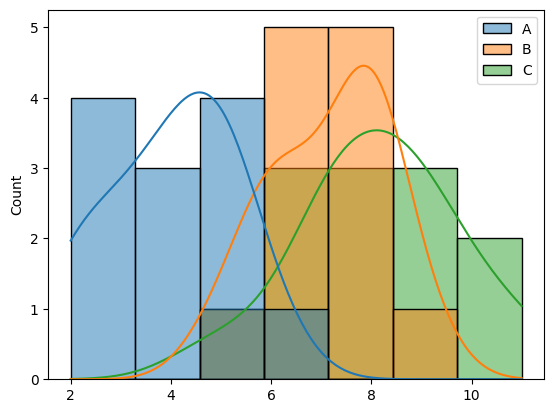

In [11]:
import seaborn as sns 

sns.histplot(df_stress, kde=True)

<Axes: >

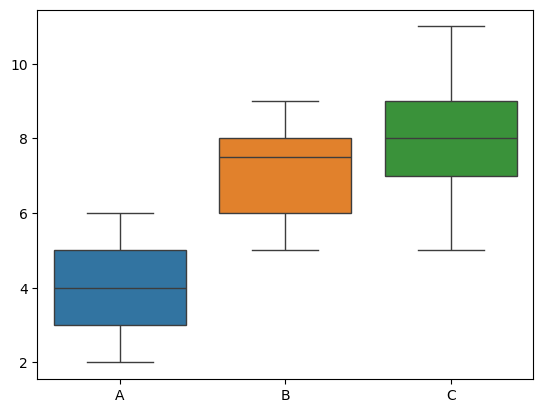

In [12]:
sns.boxplot(df_stress)

In [13]:
from scipy.stats import kruskal

kruskal(*[df_stress["A"], df_stress["B"], df_stress["C"]])

KruskalResult(statistic=np.float64(22.66179048871358), pvalue=np.float64(1.1996504475044963e-05))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html

In [14]:
from auxiliares import analise_kruskal

analise_kruskal(df_stress)

Teste de kruskal
estatistica_kruskal=22.662
Rejeita a hipótese nula (valor p: 0.000)


Como P < 0,01, rejeitamos a hipótese nula, o que nos permite concluir, ao nível de confiança de 99%, que há diferença entre os tratamentos.